In [ ]:
!pip install -U "transformers>=4.41" datasets peft accelerate bitsandbytes torch matplotlib pandas

In [ ]:
from huggingface_hub import login
login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
import os
import math
import inspect
import torch
import gc
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    Trainer,
    TrainingArguments,
    DataCollatorForLanguageModeling,
    set_seed,
    BitsAndBytesConfig,
)
from peft import LoraConfig, get_peft_model, TaskType


ATTN_TARGET_MODULES = ["q_proj", "k_proj", "v_proj", "o_proj"]
FFN_TARGET_MODULES  = ["gate_proj", "up_proj", "down_proj"]


def count_trainable_params(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    return trainable, total


def plot_results(df, out_path):
    plt.figure()
    for cfg in sorted(df["config"].unique()):
        sub = df[df["config"] == cfg].sort_values("rank")
        plt.plot(sub["rank"], sub["perplexity"], marker="o", label=cfg)
    plt.xlabel("LoRA rank (r)")
    plt.ylabel("Validation Perplexity (lower is better)")
    plt.title("LoRA Rank Sensitivity: Attention-only vs FFN-only")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(out_path)
    plt.close()


def tokenize_and_group_texts(dataset, tokenizer, seq_len):
    def tokenize_fn(batch):
        return tokenizer(batch["text"], return_attention_mask=False, truncation=False)

    tokenized = dataset.map(
        tokenize_fn,
        batched=True,
        remove_columns=dataset.column_names,
        desc="Tokenizing",
    )

    def group_fn(batch):
        concatenated = []
        for ids in batch["input_ids"]:
            concatenated.extend(ids)

        total_length = (len(concatenated) // seq_len) * seq_len
        concatenated = concatenated[:total_length]

        input_ids = [concatenated[i:i+seq_len] for i in range(0, total_length, seq_len)]
        return {"input_ids": input_ids}

    grouped = tokenized.map(group_fn, batched=True, desc=f"Grouping into {seq_len}")
    return grouped


def build_training_args_safe(**kwargs):
    """
    Build TrainingArguments, filtering unsupported kwargs to avoid
    'unexpected keyword argument' errors across 5.x variants.
    Also maps eval_strategy/evaluation_strategy rename.
    """
    sig = inspect.signature(TrainingArguments.__init__).parameters
    supported = set(sig.keys())

    # Strategy name mapping
    if "eval_strategy" in supported and "evaluation_strategy" in kwargs:
        kwargs["eval_strategy"] = kwargs.pop("evaluation_strategy")
    if "evaluation_strategy" in supported and "eval_strategy" in kwargs:
        kwargs["evaluation_strategy"] = kwargs.pop("eval_strategy")

    filtered = {k: v for k, v in kwargs.items() if k in supported}
    return TrainingArguments(**filtered)


def build_lora_model(base_model_name, target_modules, r, lora_dropout, use_4bit, bf16):
    tokenizer = AutoTokenizer.from_pretrained(base_model_name, use_fast=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    torch_dtype = torch.bfloat16 if bf16 else torch.float16

    model_kwargs = dict(
        device_map="auto",
        torch_dtype=torch_dtype,
    )

    if use_4bit:
        quant_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_use_double_quant=True,
            bnb_4bit_compute_dtype=torch_dtype,
        )
        model_kwargs["quantization_config"] = quant_config

    model = AutoModelForCausalLM.from_pretrained(base_model_name, **model_kwargs)

    # Memory helpers (good for T4)
    if hasattr(model, "gradient_checkpointing_enable"):
        # use_reentrant=False is crucial for PEFT + Gradient Checkpointing compatibility
        model.gradient_checkpointing_enable(gradient_checkpointing_kwargs={"use_reentrant": False})

    # Ensure input embeddings require grads so checkpointing works with frozen weights
    if hasattr(model, "enable_input_require_grads"):
        model.enable_input_require_grads()

    if hasattr(model, "config"):
        model.config.use_cache = False

    lora_config = LoraConfig(
        task_type=TaskType.CAUSAL_LM,
        r=r,
        lora_alpha=2 * r,           # alpha = 2r
        lora_dropout=lora_dropout,  # 0.05
        target_modules=target_modules,
        bias="none",
    )
    model = get_peft_model(model, lora_config)
    model.print_trainable_parameters()
    return model, tokenizer


def run_one(
    base_model_name,
    config_name,
    target_modules,
    rank,
    seq_len,
    lr,
    lora_dropout,
    output_root,
    num_train_epochs,
    train_bs,
    eval_bs,
    grad_accum,
    eval_steps,
    save_steps,
    logging_steps,
    warmup_ratio,
    seed,
    use_4bit,
    bf16,
):
    exp_dir = os.path.join(output_root, f"{config_name}_r{rank}")
    os.makedirs(exp_dir, exist_ok=True)

    set_seed(seed)

    model, tokenizer = build_lora_model(
        base_model_name=base_model_name,
        target_modules=target_modules,
        r=rank,
        lora_dropout=lora_dropout,
        use_4bit=use_4bit,
        bf16=bf16,
    )

    raw = load_dataset("wikitext", "wikitext-2-raw-v1")
    train_ds = tokenize_and_group_texts(raw["train"], tokenizer, seq_len)
    val_ds   = tokenize_and_group_texts(raw["validation"], tokenizer, seq_len)

    data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

    args = build_training_args_safe(
        output_dir=exp_dir,
        overwrite_output_dir=True,   # ignored if unsupported
        eval_strategy="steps",
        eval_steps=eval_steps,
        save_strategy="steps",
        save_steps=save_steps,
        logging_strategy="steps",
        logging_steps=logging_steps,
        num_train_epochs=num_train_epochs,
        learning_rate=lr,
        optim="adamw_torch",
        weight_decay=0.0,
        warmup_ratio=warmup_ratio,
        per_device_train_batch_size=train_bs,
        per_device_eval_batch_size=eval_bs,
        gradient_accumulation_steps=grad_accum,
        fp16=(not bf16),
        bf16=bf16,
        report_to="none",
        dataloader_pin_memory=False,
        save_total_limit=1,
    )

    # ✅ Transformers 5.2.0: Trainer no longer accepts tokenizer=
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        data_collator=data_collator,
    )

    trainer.train()
    metrics = trainer.evaluate()

    eval_loss = float(metrics["eval_loss"])
    perplexity = float(math.exp(eval_loss)) if eval_loss < 50 else float("inf")

    trainable, total = count_trainable_params(model)

    # --- CLEANUP STEP TO PREVENT OOM ---
    del model
    del trainer
    del tokenizer
    torch.cuda.empty_cache()
    gc.collect()

    return dict(
        config=config_name,
        rank=rank,
        eval_loss=eval_loss,
        perplexity=perplexity,
        trainable_params=trainable,
        total_params=total,
        output_dir=exp_dir,
    )

In [ ]:
BASE_MODEL = "meta-llama/Llama-3.2-3B"
OUTPUT_DIR = "/content/lora_rank_sensitivity_runs"

SEQ_LEN = 256
LR = 2e-4
LORA_DROPOUT = 0.05
RANKS = [2, 4, 8, 16]

SEED = 42
BF16 = False            # T4 -> fp16 (Changed from True to False)
USE_4BIT = True         # if bitsandbytes breaks, set False

NUM_EPOCHS = 1.0
TRAIN_BS = 1
EVAL_BS = 1
GRAD_ACCUM = 16

EVAL_STEPS = 200
SAVE_STEPS = 200
LOGGING_STEPS = 50
WARMUP_RATIO = 0.03

os.makedirs(OUTPUT_DIR, exist_ok=True)

all_results = []
configs = [
    ("attention_only", ATTN_TARGET_MODULES),
    ("ffn_only", FFN_TARGET_MODULES),
]

for cfg_name, modules in configs:
    for r in RANKS:
        print(f"\n=== Running {cfg_name}, rank={r} ===")
        res = run_one(
            base_model_name=BASE_MODEL,
            config_name=cfg_name,
            target_modules=modules,
            rank=r,
            seq_len=SEQ_LEN,
            lr=LR,
            lora_dropout=LORA_DROPOUT,
            output_root=OUTPUT_DIR,
            num_train_epochs=NUM_EPOCHS,
            train_bs=TRAIN_BS,
            eval_bs=EVAL_BS,
            grad_accum=GRAD_ACCUM,
            eval_steps=EVAL_STEPS,
            save_steps=SAVE_STEPS,
            logging_steps=LOGGING_STEPS,
            warmup_ratio=WARMUP_RATIO,
            seed=SEED,
            use_4bit=USE_4BIT,
            bf16=BF16,
        )
        print("Result:", res)
        all_results.append(res)

        df = pd.DataFrame(all_results)
        df.to_csv(os.path.join(OUTPUT_DIR, "results.csv"), index=False)
        plot_results(df, os.path.join(OUTPUT_DIR, "ppl_vs_rank.png"))

print("\nDone.")
print("Saved results:", os.path.join(OUTPUT_DIR, "results.csv"))
print("Saved plot:   ", os.path.join(OUTPUT_DIR, "ppl_vs_rank.png"))


=== Running attention_only, rank=2 ===


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

trainable params: 1,146,880 || all params: 3,213,896,704 || trainable%: 0.0357


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step,Training Loss,Validation Loss
200,2.372020,2.329674
400,2.296407,2.295261
600,2.273773,2.289275


...

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

trainable params: 15,138,816 || all params: 3,227,888,640 || trainable%: 0.4690


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step,Training Loss,Validation Loss
200,2.274274,2.282151
400,2.251721,2.268707


Step,Training Loss,Validation Loss
200,2.274274,2.282151
400,2.251721,2.268707
600,2.224574,2.263257


In [ ]:
BASE_MODEL = "meta-llama/Llama-3.2-3B"
OUTPUT_DIR = "/content/lora_rank_sensitivity_runs"

SEQ_LEN = 256
LR = 2e-4
LORA_DROPOUT = 0.05
RANKS = [16]

SEED = 42
BF16 = False            # T4 -> fp16 (Changed from True to False)
USE_4BIT = True         # if bitsandbytes breaks, set False

NUM_EPOCHS = 1.0
TRAIN_BS = 1
EVAL_BS = 1
GRAD_ACCUM = 16

EVAL_STEPS = 200
SAVE_STEPS = 200
LOGGING_STEPS = 50
WARMUP_RATIO = 0.03

os.makedirs(OUTPUT_DIR, exist_ok=True)

all_results = []
configs = [
    ("ffn_only", FFN_TARGET_MODULES)
]

for cfg_name, modules in configs:
    for r in RANKS:
        print(f"\n=== Running {cfg_name}, rank={r} ===")
        res = run_one(
            base_model_name=BASE_MODEL,
            config_name=cfg_name,
            target_modules=modules,
            rank=r,
            seq_len=SEQ_LEN,
            lr=LR,
            lora_dropout=LORA_DROPOUT,
            output_root=OUTPUT_DIR,
            num_train_epochs=NUM_EPOCHS,
            train_bs=TRAIN_BS,
            eval_bs=EVAL_BS,
            grad_accum=GRAD_ACCUM,
            eval_steps=EVAL_STEPS,
            save_steps=SAVE_STEPS,
            logging_steps=LOGGING_STEPS,
            warmup_ratio=WARMUP_RATIO,
            seed=SEED,
            use_4bit=USE_4BIT,
            bf16=BF16,
        )
        print("Result:", res)
        all_results.append(res)

        df = pd.DataFrame(all_results)
        df.to_csv(os.path.join(OUTPUT_DIR, "results.csv"), index=False)
        plot_results(df, os.path.join(OUTPUT_DIR, "ppl_vs_rank.png"))

print("\nDone.")
print("Saved results:", os.path.join(OUTPUT_DIR, "results.csv"))
print("Saved plot:   ", os.path.join(OUTPUT_DIR, "ppl_vs_rank.png"))


=== Running ffn_only, rank=16 ===


config.json:   0%|          | 0.00/844 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/50.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

...

Grouping into 256:   0%|          | 0/3760 [00:00<?, ? examples/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step,Training Loss,Validation Loss
200,2.274151,2.282332
400,2.251676,2.268681


Step,Training Loss,Validation Loss
200,2.274151,2.282332
400,2.251676,2.268681
600,2.224321,2.263179


Result: {'config': 'ffn_only', 'rank': 16, 'eval_loss': 2.26318621635437, 'perplexity': 9.613671657536319, 'trainable_params': 15138816, 'total_params': 1818602496, 'output_dir': '/content/lora_rank_sensitivity_runs/ffn_only_r16'}

Done.
Saved results: /content/lora_rank_sensitivity_runs/results.csv
Saved plot:    /content/lora_rank_sensitivity_runs/ppl_vs_rank.png


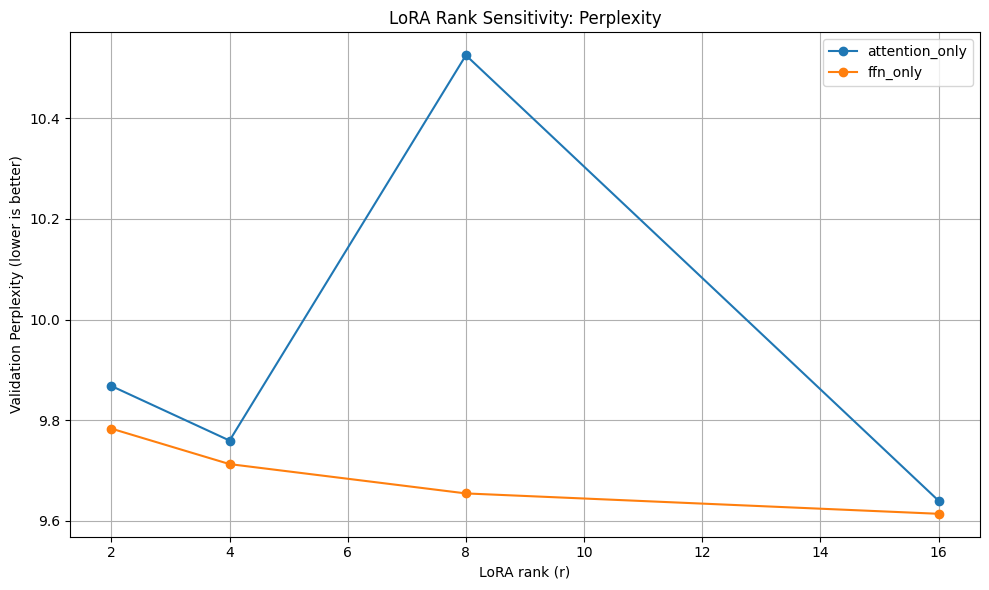

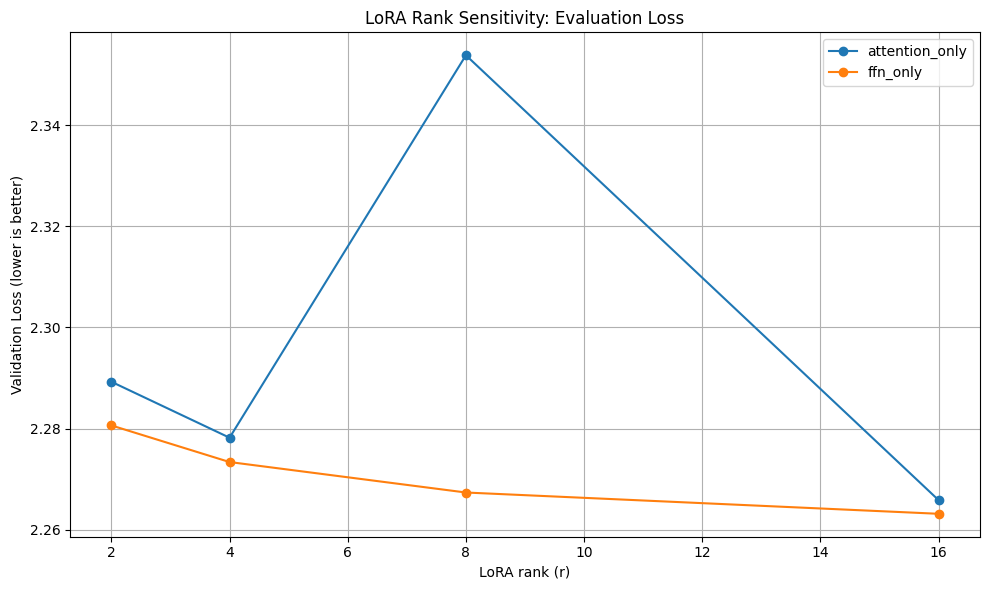

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Hardcoded results from the above run
all_results = [
    {'config': 'attention_only', 'rank': 2, 'eval_loss': 2.2892751693725586, 'perplexity': 9.867782617315767, 'trainable_params': 1146880, 'total_params': 1804610560, 'output_dir': '/content/lora_rank_sensitivity_runs/attention_only_r2'},
    {'config': 'attention_only', 'rank': 4, 'eval_loss': 2.27821946144104, 'perplexity': 9.759288141477974, 'trainable_params': 2293760, 'total_params': 1805757440, 'output_dir': '/content/lora_rank_sensitivity_runs/attention_only_r4'},
    {'config': 'attention_only', 'rank': 8, 'eval_loss': 2.3537964820861816, 'perplexity': 10.525453663776132, 'trainable_params': 4587520, 'total_params': 1808051200, 'output_dir': '/content/lora_rank_sensitivity_runs/attention_only_r8'},
    {'config': 'attention_only', 'rank': 16, 'eval_loss': 2.265878200531006, 'perplexity': 9.639586374872433, 'trainable_params': 9175040, 'total_params': 1812638720, 'output_dir': '/content/lora_rank_sensitivity_runs/attention_only_r16'},
    {'config': 'ffn_only', 'rank': 2, 'eval_loss': 2.2806499004364014, 'perplexity': 9.783036343532043, 'trainable_params': 1892352, 'total_params': 1805356032, 'output_dir': '/content/lora_rank_sensitivity_runs/ffn_only_r2'},
    {'config': 'ffn_only', 'rank': 4, 'eval_loss': 2.2734129428863525, 'perplexity': 9.712492494110899, 'trainable_params': 3784704, 'total_params': 1807248384, 'output_dir': '/content/lora_rank_sensitivity_runs/ffn_only_r4'},
    {'config': 'ffn_only', 'rank': 8, 'eval_loss': 2.2673916816711426, 'perplexity': 9.65418675296096, 'trainable_params': 7569408, 'total_params': 1811033088, 'output_dir': '/content/lora_rank_sensitivity_runs/ffn_only_r8'},
    {'config': 'ffn_only', 'rank': 16, 'eval_loss': 2.26318621635437, 'perplexity': 9.613671657536319, 'trainable_params': 15138816, 'total_params': 1818602496, 'output_dir': '/content/lora_rank_sensitivity_runs/ffn_only_r16'}
]

df = pd.DataFrame(all_results)

# Plot Perplexity vs. Rank
plt.figure(figsize=(10, 6))
for cfg in sorted(df["config"].unique()):
    sub = df[df["config"] == cfg].sort_values("rank")
    plt.plot(sub["rank"], sub["perplexity"], marker="o", label=cfg)
plt.xlabel("LoRA rank (r)")
plt.ylabel("Validation Perplexity (lower is better)")
plt.title("LoRA Rank Sensitivity: Perplexity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot Loss vs. Rank
plt.figure(figsize=(10, 6))
for cfg in sorted(df["config"].unique()):
    sub = df[df["config"] == cfg].sort_values("rank")
    plt.plot(sub["rank"], sub["eval_loss"], marker="o", label=cfg)
plt.xlabel("LoRA rank (r)")
plt.ylabel("Validation Loss (lower is better)")
plt.title("LoRA Rank Sensitivity: Evaluation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()